##Libraries


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score,classification_report
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")
from google.colab import drive


In [2]:
!pip install --upgrade xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 5.3 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.4
    Uninstalling xgboost-2.1.4:
      Successfully uninstalled xgboost-2.1.4


##Dataset Upload

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df=pd.read_csv('/content/drive/MyDrive/Heart Attack Data Set.csv')

##Preprocessing

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
df.tail()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [7]:
print('Number of rows are :-',df.shape[0], ',and number of columns are :-',df.shape[1])


Number of rows are :- 303 ,and number of columns are :- 14


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [10]:
df.columns


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [11]:
df.duplicated().sum()


np.int64(1)

In [12]:
df.drop_duplicates(inplace=True)
print('Number of rows are :',df.shape[0], ',and number of columns are :',df.shape[1])

Number of rows are : 302 ,and number of columns are : 14


In [13]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


##Analysis

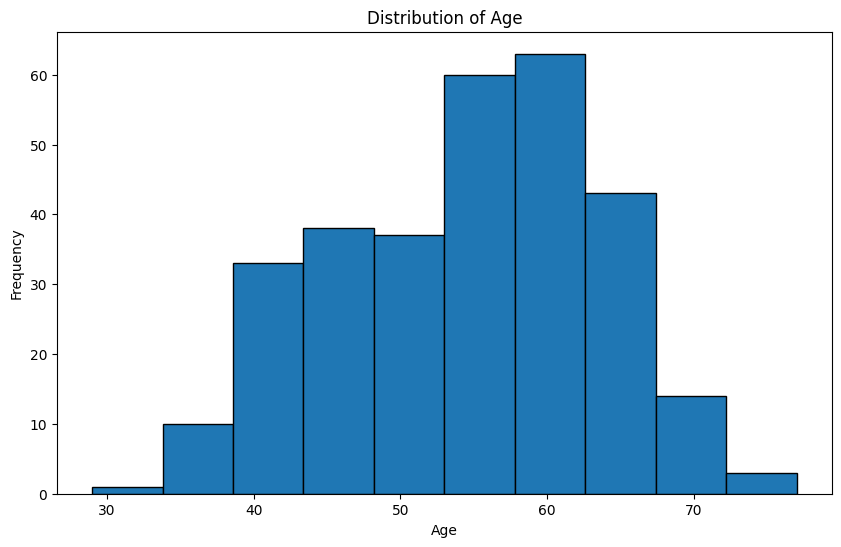

In [14]:
# prompt: hist plot

# Assuming df is already loaded as in your provided code

plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=10, edgecolor='black')  # Adjust 'bins' as needed
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()


In [15]:
# prompt: df_gender = df.groupby('gender').agg({'gender' : 'count', **{col : 'mean' for col in numeric_column}})
# df_gender.rename(inplace = True, columns = {'gender' : 'gender_count'})
# df_gender = df_gender.reset_index()
# df_gender.index = np.arange(1, 3)
# make it for sex

numeric_column = df.select_dtypes(include=np.number).columns.tolist()
df_sex = df.groupby('sex').agg({'sex' : 'count', **{col : 'mean' for col in numeric_column}})
df_sex.rename(inplace = True, columns = {'sex' : 'sex_count'})
df_sex = df_sex.reset_index()
df_sex.index = np.arange(1, len(df_sex) + 1)


In [16]:
df_sex.T

,1,2
sex,0.000000,1.000000
sex_count,0.000000,1.000000
age,55.677083,53.834951
cp,1.041667,0.927184
trestbps,133.083333,130.912621
chol,261.302083,239.601942
fbs,0.125000,0.160194
restecg,0.572917,0.504854
thalach,151.125000,148.844660
exang,0.229167,0.373786


In [17]:
for i in list(df.columns):
    print("{} -- {}".format(i, df[i].value_counts().shape[0]))

age -- 41
sex -- 2
cp -- 4
trestbps -- 49
chol -- 152
fbs -- 2
restecg -- 3
thalach -- 91
exang -- 2
oldpeak -- 40
slope -- 3
ca -- 5
thal -- 4
target -- 2


In [18]:
categorical_list = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]

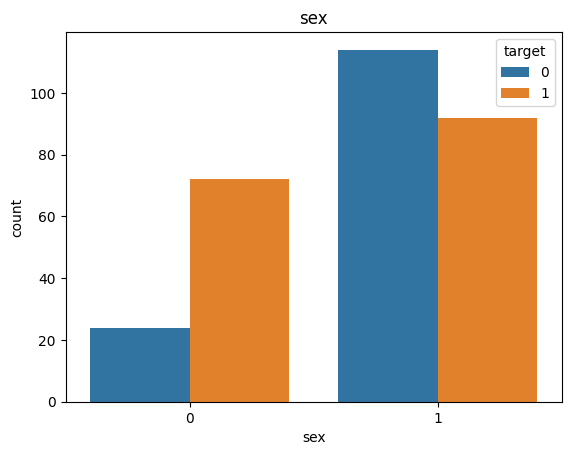

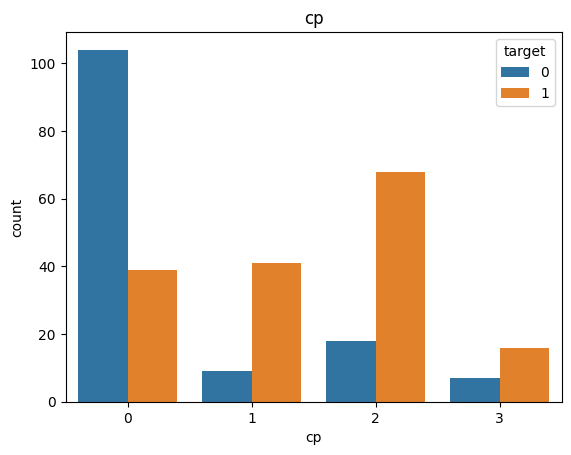

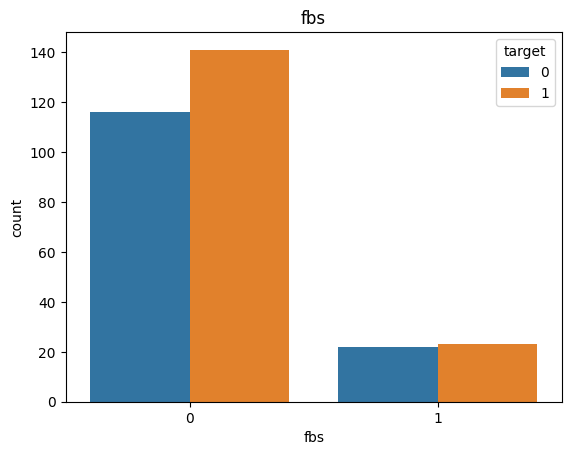

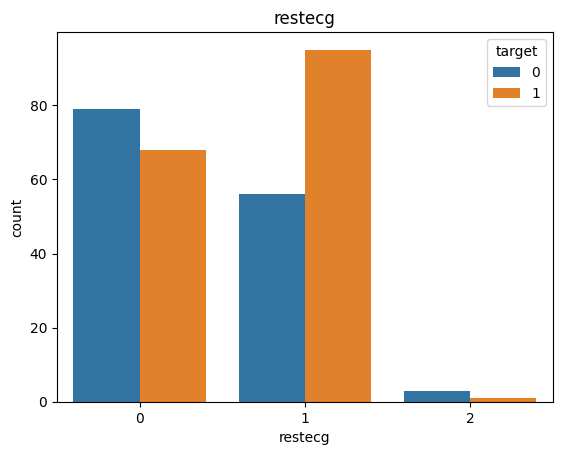

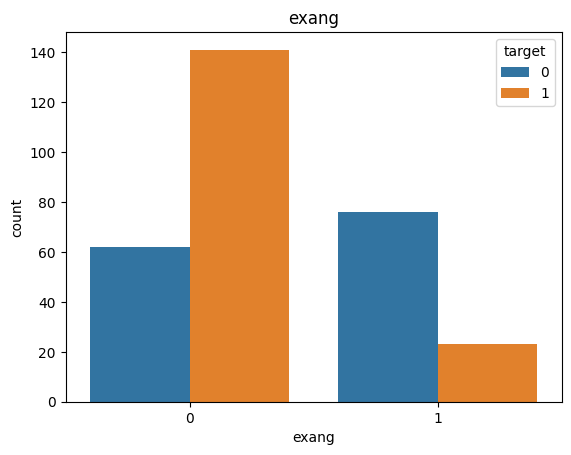

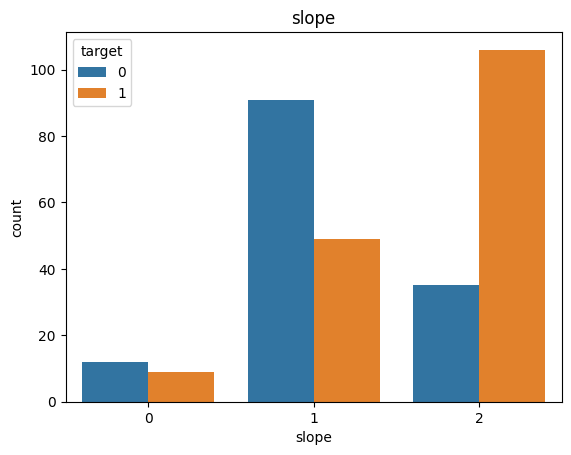

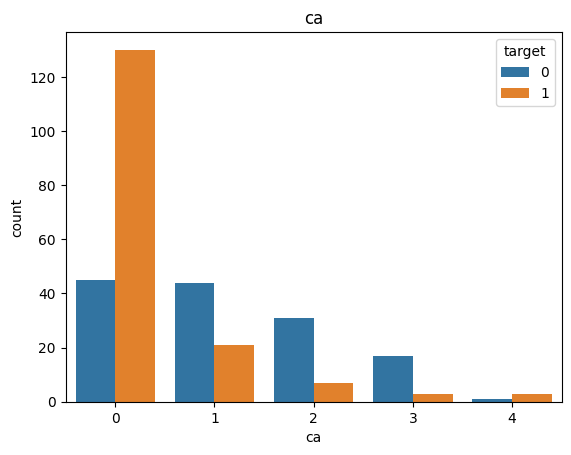

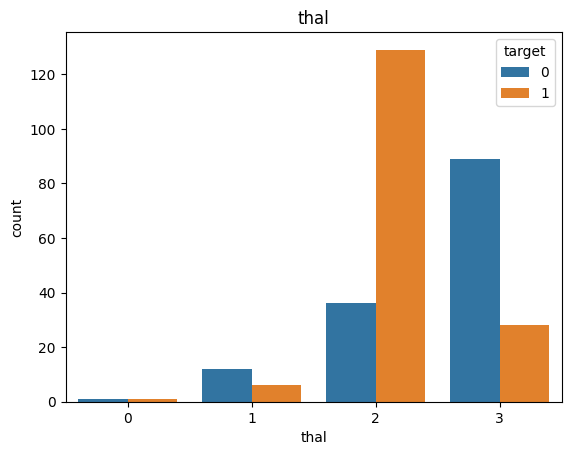

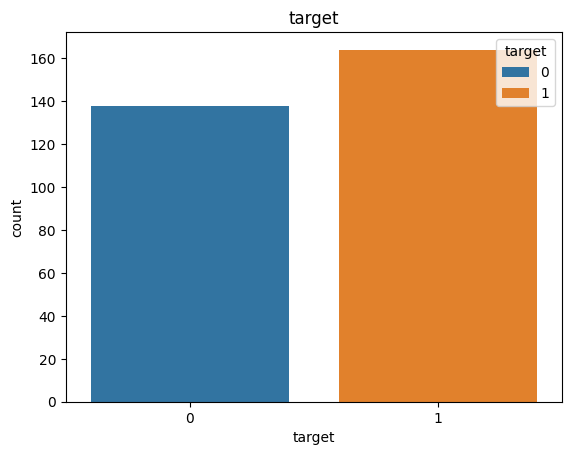

In [19]:
df_categoric = df.loc[:, categorical_list]
for i in categorical_list:
    plt.figure()
    sns.countplot(x = i, data = df_categoric, hue = "target")
    plt.title(i)

In [20]:
numeric_list = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]

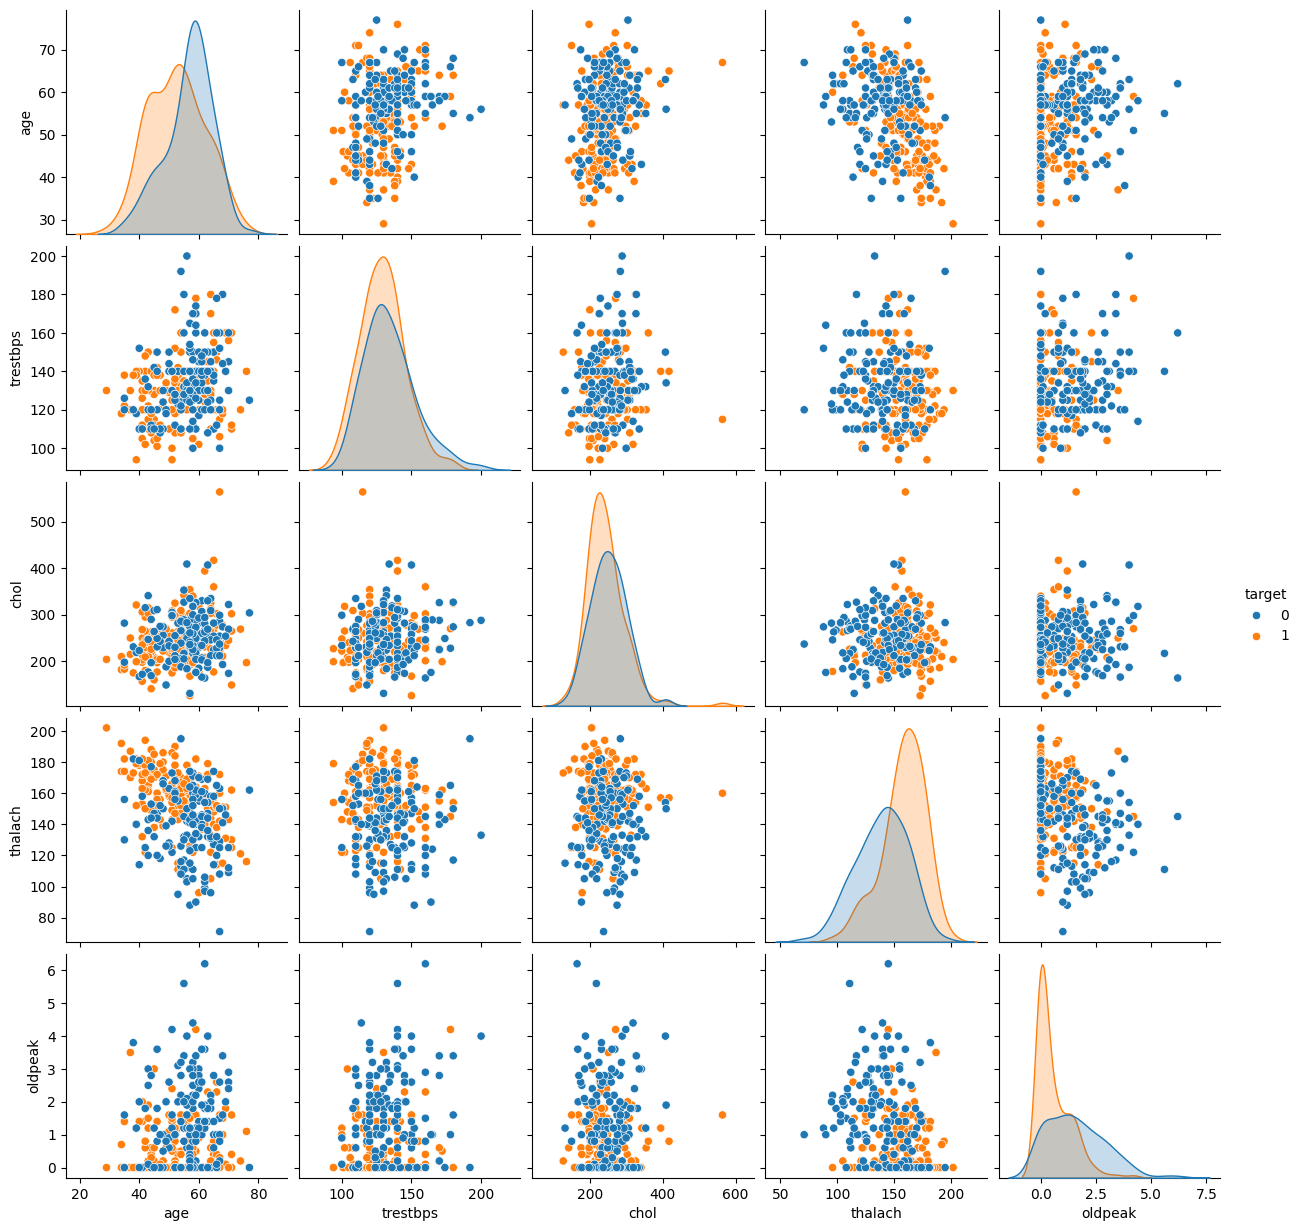

In [21]:
df_numeric = df.loc[:, numeric_list]
sns.pairplot(data = df_numeric, hue = "target", diag_kind = "kde")

In [22]:
scaler = StandardScaler()
scaler

StandardScaler()

In [23]:
scaled_array = scaler.fit_transform(df[numeric_list[:-1]])

In [24]:
scaled_array


array([[ 0.94979429,  0.76406571, -0.26128493,  0.01882584,  1.08402203],
       [-1.92854796, -0.09140084,  0.06774054,  1.63697881,  2.11892611],
       [-1.48572607, -0.09140084, -0.82256367,  0.98097085,  0.30784398],
       ...,
       [ 1.50332164,  0.70703461, -1.0354625 , -0.37477894,  2.0326841 ],
       [ 0.28556146, -0.09140084, -2.23543773, -1.51185941,  0.13535997],
       [ 0.28556146, -0.09140084, -0.20322161,  1.06843858, -0.8995441 ]])

In [25]:
pd.DataFrame(scaled_array).describe().T

,count,mean,std,min,25%,50%,75%,max
0,302.0,-2.588070e-16,1.00166,-2.814192,-0.710788,0.119503,0.728383,2.499671
1,302.0,-7.058372e-16,1.00166,-2.144521,-0.661712,-0.091401,0.478910,3.900776
2,302.0,8.822964e-18,1.00166,-2.332210,-0.687083,-0.116127,0.546763,6.145034
3,302.0,-5.646697e-16,1.00166,-3.436149,-0.713716,0.128160,0.718568,2.292987
4,302.0,-1.646953e-16,1.00166,-0.899544,-0.899544,-0.209608,0.480328,4.447460


In [26]:
scaler = MinMaxScaler()
scaler

MinMaxScaler()

In [27]:
normalized_array = scaler.fit_transform(df[numeric_list[:-1]])
normalized_array

array([[0.70833333, 0.48113208, 0.24429224, 0.60305344, 0.37096774],
       [0.16666667, 0.33962264, 0.28310502, 0.88549618, 0.56451613],
       [0.25      , 0.33962264, 0.17808219, 0.77099237, 0.22580645],
       ...,
       [0.8125    , 0.47169811, 0.15296804, 0.53435115, 0.5483871 ],
       [0.58333333, 0.33962264, 0.01141553, 0.33587786, 0.19354839],
       [0.58333333, 0.33962264, 0.25114155, 0.78625954, 0.        ]])

In [28]:
pd.DataFrame(normalized_array).describe().T

,count,mean,std,min,25%,50%,75%,max
0,302.0,0.529594,0.188499,0.0,0.395833,0.552083,0.666667,1.0
1,302.0,0.354742,0.165692,0.0,0.245283,0.339623,0.433962,1.0
2,302.0,0.275114,0.118159,0.0,0.194064,0.261416,0.339612,1.0
3,302.0,0.599767,0.174836,0.0,0.475191,0.622137,0.725191,1.0
4,302.0,0.168233,0.187331,0.0,0.000000,0.129032,0.258065,1.0


In [29]:
df_dummy = pd.DataFrame(scaled_array, columns = numeric_list[:-1])
df_dummy.head()

,age,trestbps,chol,thalach,oldpeak
0,0.949794,0.764066,-0.261285,0.018826,1.084022
1,-1.928548,-0.091401,0.067741,1.636979,2.118926
2,-1.485726,-0.091401,-0.822564,0.980971,0.307844
3,0.174856,-0.661712,-0.203222,1.243374,-0.209608
4,0.285561,-0.661712,2.080602,0.587366,-0.382092


In [30]:
df_dummy = pd.concat([df_dummy, df.loc[:, "target"]], axis = 1)
df_dummy.head()

,age,trestbps,chol,thalach,oldpeak,target
0,0.949794,0.764066,-0.261285,0.018826,1.084022,1.0
1,-1.928548,-0.091401,0.067741,1.636979,2.118926,1.0
2,-1.485726,-0.091401,-0.822564,0.980971,0.307844,1.0
3,0.174856,-0.661712,-0.203222,1.243374,-0.209608,1.0
4,0.285561,-0.661712,2.080602,0.587366,-0.382092,1.0


In [31]:
data_melted = pd.melt(df_dummy, id_vars = "target", var_name = "features", value_name = "value")
data_melted.head(20)

,target,features,value
0,1.0,age,0.949794
1,1.0,age,-1.928548
2,1.0,age,-1.485726
3,1.0,age,0.174856
4,1.0,age,0.285561
5,1.0,age,0.285561
6,1.0,age,0.174856
7,1.0,age,-1.153610
8,1.0,age,-0.267966
9,1.0,age,0.285561


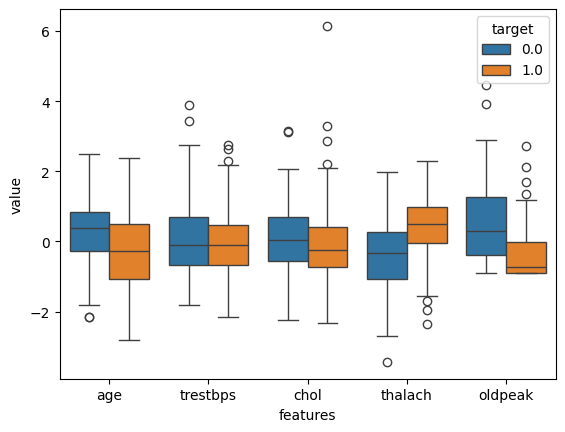

In [32]:
plt.figure()
sns.boxplot(x = "features", y = "value", hue = "target", data = data_melted)
plt.show();

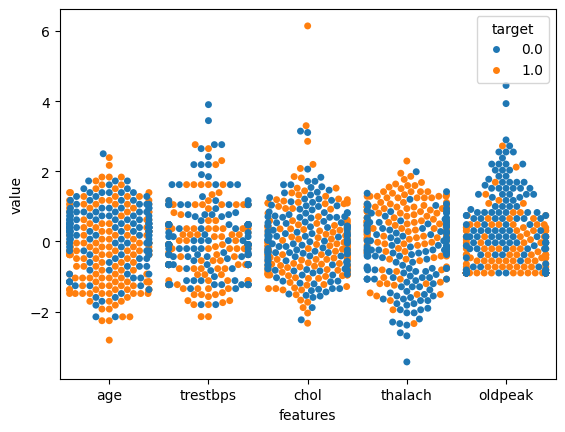

In [33]:
plt.figure()
sns.swarmplot(x = "features", y = "value", hue = "target", data = data_melted)
plt.show();

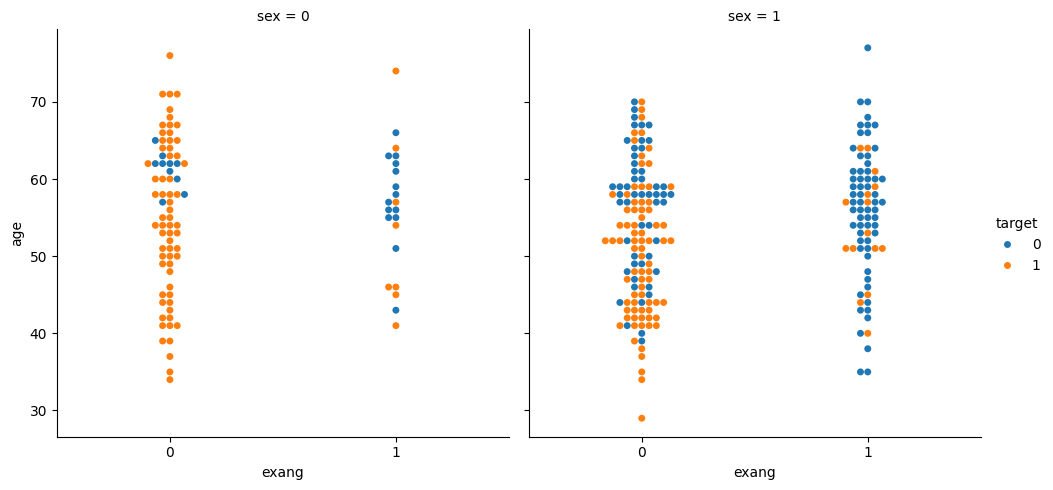

In [34]:
sns.catplot(x = "exang", y = "age", hue = "target", col = "sex", kind = "swarm", data = df)
plt.show();

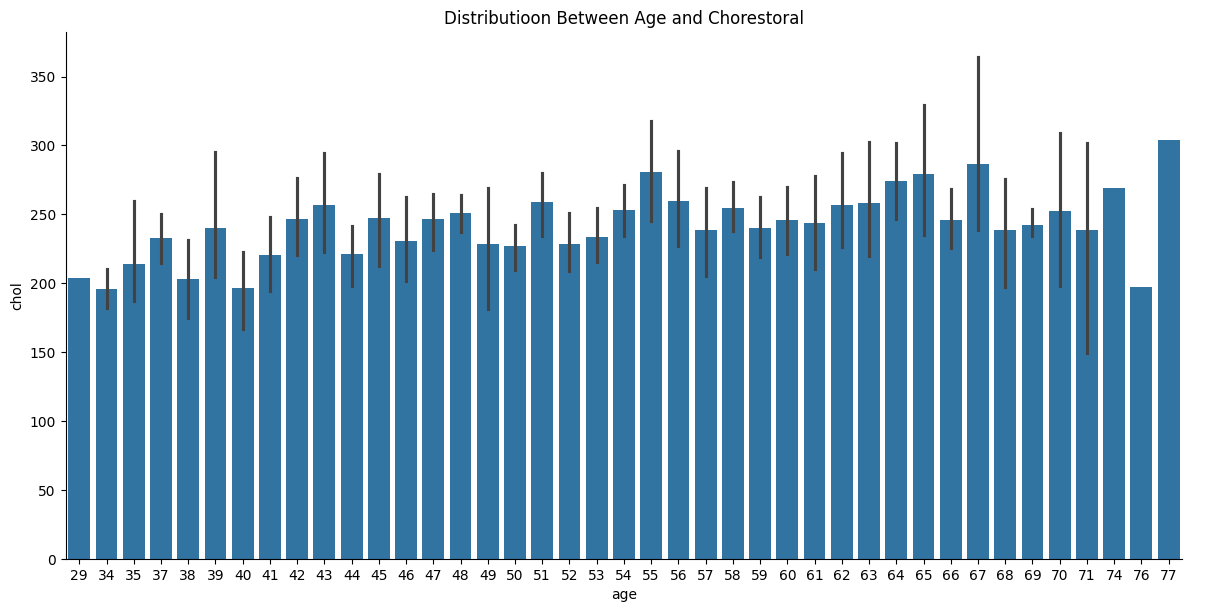

In [35]:
#distribution between age and cholestoral
sns.catplot(x = "age", y = "chol", data = df, kind = "bar", height = 6, aspect = 2)
plt.title("Distributioon Between Age and Chorestoral")
plt.show();

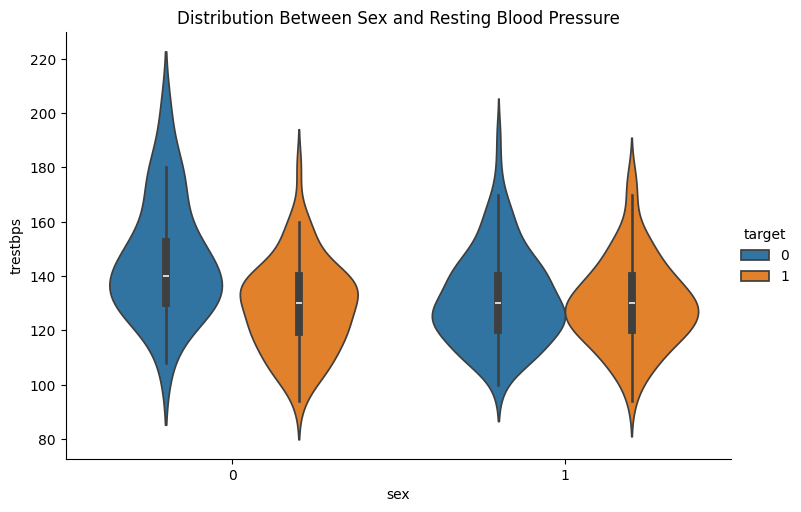

In [36]:
sns.catplot(x="sex", y = "trestbps", hue="target", data=df, kind="violin", height=5, aspect=1.5)
plt.title("Distribution Between Sex and Resting Blood Pressure")
plt.show()

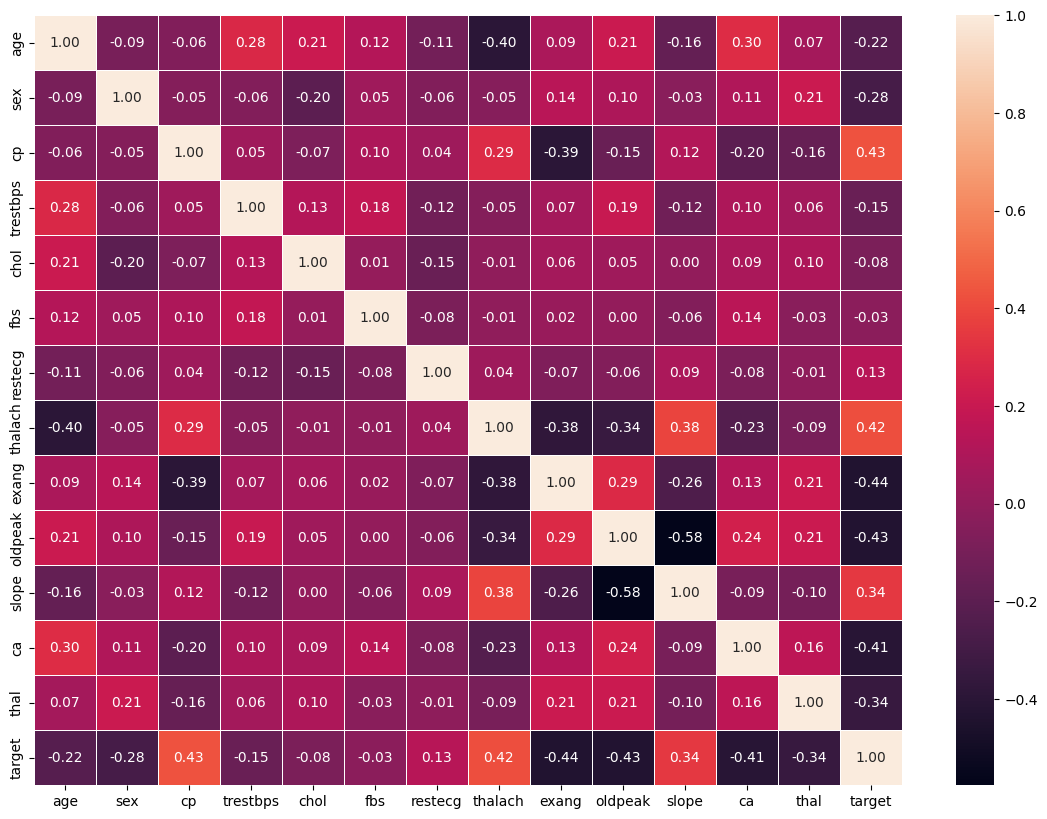

In [37]:
plt.figure(figsize = (14, 10))
sns.heatmap(df.corr(), annot = True, fmt = ".2f", linewidths = .7)
plt.show();

In [38]:
numeric_list = ["age", "trestbps", "chol", "thalach", "oldpeak"]
df_numeric = df.loc[:, numeric_list]
df_numeric.head()

,age,trestbps,chol,thalach,oldpeak
0,63,145,233,150,2.3
1,37,130,250,187,3.5
2,41,130,204,172,1.4
3,56,120,236,178,0.8
4,57,120,354,163,0.6


In [39]:
df_numeric.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


In [40]:
# outlier detection
for i in numeric_list:

    # IQR
    Q1 = np.percentile(df.loc[:, i],25)
    Q3 = np.percentile(df.loc[:, i],75)

    IQR = Q3 - Q1

    print("Old shape: ", df.loc[:, i].shape)

    # upper bound
    upper = np.where(df.loc[:, i] >= (Q3 + 1.5 * IQR))

    # lower bound
    lower = np.where(df.loc[:, i] <= (Q1 - 1.5 * IQR))

    print("{} -- {}".format(upper, lower))

    try:
        df.drop(upper[0], inplace = True)
    except: print("KeyError: {} not found in axis".format(upper[0]))

    try:
        df.drop(lower[0], inplace = True)
    except:  print("KeyError: {} not found in axis".format(lower[0]))

    print("New shape: ", df.shape)


Old shape:  (302,)
(array([], dtype=int64),) -- (array([], dtype=int64),)
New shape:  (302, 14)
Old shape:  (302,)
(array([  8, 101, 110, 152, 194, 202, 222, 227, 240, 247, 259, 265, 291]),) -- (array([], dtype=int64),)
New shape:  (289, 14)
Old shape:  (289,)
(array([ 27,  84,  95, 213, 236]),) -- (array([], dtype=int64),)
New shape:  (284, 14)
Old shape:  (284,)
(array([], dtype=int64),) -- (array([228, 254, 278]),)
New shape:  (281, 14)
Old shape:  (281,)
(array([194, 209, 210, 211, 233, 273]),) -- (array([], dtype=int64),)
KeyError: [194 209 210 211 233 273] not found in axis
New shape:  (281, 14)


In [41]:
df1 = df.copy()

In [42]:
df1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [43]:
x = df1.drop(["target"], axis = 1)
y = df1[["target"]]

In [44]:
scaler = StandardScaler()
scaler

StandardScaler()

In [45]:
x[numeric_list[:-1]] = scaler.fit_transform(x[numeric_list[:-1]])

In [46]:
x[numeric_list].head()

,age,trestbps,chol,thalach,oldpeak
0,0.973124,0.855229,-0.245056,-0.006064,2.3
1,-1.912283,-0.044843,0.081480,1.610412,3.5
2,-1.468374,-0.044843,-0.802088,0.955084,1.4
3,0.196284,-0.644891,-0.187432,1.217215,0.8
4,0.307261,-0.644891,2.079113,0.561887,0.6


In [47]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)
print("x_train: {}".format(x_train.shape))
print("x_test: {}".format(x_test.shape))
print("y_train: {}".format(y_train.shape))
print("y_test: {}".format(y_test.shape))

x_train: (210, 13)
x_test: (71, 13)
y_train: (210, 1)
y_test: (71, 1)


##Models

In [48]:

log_model = LogisticRegression().fit(x_train, y_train)
y_pred_log = log_model.predict(x_test)
acc_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        30
           1       0.90      0.90      0.90        41

    accuracy                           0.89        71
   macro avg       0.88      0.88      0.88        71
weighted avg       0.89      0.89      0.89        71



In [49]:
log_model_tuned = LogisticRegression(penalty='l2', solver='liblinear').fit(x_train, y_train)
y_pred_log_tuned = log_model_tuned.predict(x_test)
acc_log_tuned = accuracy_score(y_test, y_pred_log_tuned)
print("Tuned Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_tuned))

Tuned Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        30
           1       0.90      0.85      0.88        41

    accuracy                           0.86        71
   macro avg       0.85      0.86      0.86        71
weighted avg       0.86      0.86      0.86        71



In [50]:
xgb_model = XGBClassifier().fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.90      0.81        30
           1       0.91      0.76      0.83        41

    accuracy                           0.82        71
   macro avg       0.82      0.83      0.82        71
weighted avg       0.83      0.82      0.82        71



In [51]:
xgb_tuned = XGBClassifier(learning_rate=0.1, max_depth=3, n_estimators=100).fit(x_train, y_train)
y_pred_xgb_tuned = xgb_tuned.predict(x_test)
acc_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
print("Tuned XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb_tuned))

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.83      0.78        30
           1       0.86      0.78      0.82        41

    accuracy                           0.80        71
   macro avg       0.80      0.81      0.80        71
weighted avg       0.81      0.80      0.80        71



In [52]:
from sklearn.neural_network import MLPClassifier
mlpc = MLPClassifier().fit(x_train, y_train)
y_pred_nn = mlpc.predict(x_test)
acc_nn = accuracy_score(y_test, y_pred_nn)
print("Neural Networks Classification Report:")
print(classification_report(y_test, y_pred_nn))

Neural Networks Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85        30
           1       0.90      0.88      0.89        41

    accuracy                           0.87        71
   macro avg       0.87      0.87      0.87        71
weighted avg       0.87      0.87      0.87        71



In [53]:
mlpc_tuned = MLPClassifier(activation='relu', alpha=0.1, hidden_layer_sizes=(100, 100, 100), solver='sgd')
mlpc_tuned.fit(x_train, y_train)
y_pred_nn_tuned = mlpc_tuned.predict(x_test)
acc_nn_tuned = accuracy_score(y_test, y_pred_nn_tuned)
print("Tuned Neural Networks Classification Report:")
print(classification_report(y_test, y_pred_nn_tuned))


Tuned Neural Networks Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.81        30
           1       0.87      0.83      0.85        41

    accuracy                           0.83        71
   macro avg       0.83      0.83      0.83        71
weighted avg       0.83      0.83      0.83        71



In [54]:
from sklearn.ensemble import GradientBoostingClassifier
gbm_model = GradientBoostingClassifier().fit(x_train, y_train)
y_pred_gbm = gbm_model.predict(x_test)
acc_gbm = accuracy_score(y_test, y_pred_gbm)
print("GBM Classification Report:")
print(classification_report(y_test, y_pred_gbm))

GBM Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.77      0.73        30
           1       0.82      0.76      0.78        41

    accuracy                           0.76        71
   macro avg       0.76      0.76      0.76        71
weighted avg       0.77      0.76      0.76        71



In [55]:
print("1. Base Models (Non-Tuned)")

print(f"Accuracy Logistic Regression: {acc_log:.4f}")
print(f"Accuracy XGBoost: {acc_xgb:.4f}")
print(f"Accuracy Neural Networks (MLP): {acc_nn:.4f}")
print(f"Accuracy GBM: {acc_gbm:.4f}")


1. Base Models (Non-Tuned)
Accuracy Logistic Regression: 0.8873
Accuracy XGBoost: 0.8169
Accuracy Neural Networks (MLP): 0.8732
Accuracy GBM: 0.7606


In [56]:
print("2. Tuned Models")

print(f"Accuracy Tuned Logistic Regression: {acc_log_tuned:.4f}")
print(f"Accuracy Tuned XGBoost: {acc_xgb_tuned:.4f}")
print(f"Accuracy Tuned Neural Networks: {acc_nn_tuned:.4f}")

2. Tuned Models
Accuracy Tuned Logistic Regression: 0.8592
Accuracy Tuned XGBoost: 0.8028
Accuracy Tuned Neural Networks: 0.8310


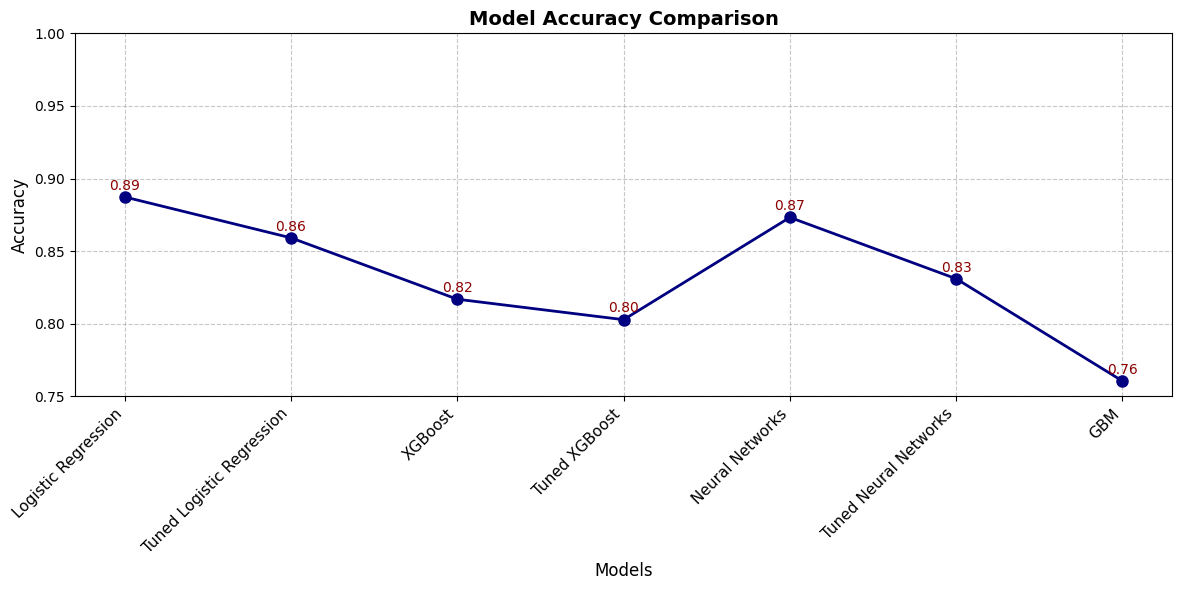

In [57]:
import matplotlib.pyplot as plt

# Define the models and accuracies
models = [
    "Logistic Regression",
    "Tuned Logistic Regression",
    "XGBoost",
    "Tuned XGBoost",
    "Neural Networks",
    "Tuned Neural Networks",
    "GBM"
]

accuracies = [
    acc_log,
    acc_log_tuned,
    acc_xgb,
    acc_xgb_tuned,
    acc_nn,
    acc_nn_tuned,
    acc_gbm
]

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(models, accuracies, marker='o', linestyle='-', linewidth=2, markersize=8, color='navy')

# Adding data labels on points
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f"{acc:.2f}", ha='center', fontsize=10, color='darkred')

plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.ylim(0.75, 1.0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


In [58]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import xgboost as xgb

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# Train XGBoost model
#best_model = LogisticRegression()
#best_model.fit(X_train_scaled, y_train)
best_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=1.5)
best_model.fit(X_train_scaled, y_train)

# Metadata for full forms
column_info = {
    'age': "Age",
    'sex': "Sex (1 = Male, 0 = Female)",
    'cp': "Chest Pain Type (0-3)",
    'trestbps': "Resting Blood Pressure",
    'chol': "Serum Cholesterol in mg/dl",
    'fbs': "Fasting Blood Sugar (1 if >120 mg/dl, 0 otherwise)",
    'restecg': "Resting Electrocardiographic Results (0-2)",
    'thalach': "Maximum Heart Rate Achieved",
    'exang': "Exercise Induced Angina (1 = yes; 0 = no)",
    'oldpeak': "ST depression induced by exercise relative to rest",
    'slope': "The slope of the peak exercise ST segment (0-2)",
    'ca': "Number of major vessels (0-3) colored by fluoroscopy",
    'thal': "Thalassemia (3 = normal; 6 = fixed defect; 7 = reversible defect)",
    'target': "Diagnosis of Heart Disease (1 = Yes, 0 = No)"
}

# Function to get user input and make a prediction
def predict_target():
    user_input = {}

    for col in x.columns:
        min_val = df[col].min()
        max_val = df[col].max()
        full_form = column_info.get(col, col)

        print(f"\nInput for {full_form}")
        print(f"Typical Range: {min_val} to {max_val}")

        while True:
            try:
                value = float(input(f"Enter value for {col}: "))
                user_input[col] = value
                break
            except ValueError:
                print("Invalid input. Please enter a valid number.")

    # Convert to DataFrame
    user_df = pd.DataFrame([user_input])

    # Apply scaling
    user_df_scaled = scaler.transform(user_df)

    # Get probability from XGBoost
    prob = best_model.predict_proba(user_df_scaled)[0][1]

    # Custom threshold (e.g., 0.12)
    threshold = 0.12

    print(f"\nPredicted Heart Attack Risk Score: {prob:.2f}")

    if prob > threshold:
        print("⚠️ Heart Attack Chance!")
    else:
        print("✅ No Chance of Heart Attack")

# Call the function
predict_target()



Input for Age
Typical Range: 29 to 77
Enter value for age: 30

Input for Sex (1 = Male, 0 = Female)
Typical Range: 0 to 1
Enter value for sex: 0

Input for Chest Pain Type (0-3)
Typical Range: 0 to 3
Enter value for cp: 1

Input for Resting Blood Pressure
Typical Range: 94 to 200
Enter value for trestbps: 100

Input for Serum Cholesterol in mg/dl
Typical Range: 126 to 564
Enter value for chol: 130

Input for Fasting Blood Sugar (1 if >120 mg/dl, 0 otherwise)
Typical Range: 0 to 1
Enter value for fbs: 1

Input for Resting Electrocardiographic Results (0-2)
Typical Range: 0 to 2
Enter value for restecg: 2

Input for Maximum Heart Rate Achieved
Typical Range: 71 to 202
Enter value for thalach: 71

Input for Exercise Induced Angina (1 = yes; 0 = no)
Typical Range: 0 to 1
Enter value for exang: 1

Input for ST depression induced by exercise relative to rest
Typical Range: 0.0 to 6.2
Enter value for oldpeak: 5.0

Input for The slope of the peak exercise ST segment (0-2)
Typical Range: 0 to 